# Notebook 04 -- McNemar's Test: Classifier Comparison

**Data source:** `data/processed/test_predictions.parquet`  

**Purpose:** Determine whether the difference in errors between Logistic Regression
and Random Forest is statistically significant, using McNemar's test on paired
predictions from the same held-out test set.

**Why McNemar's test?**  
Standard model comparison using accuracy or cross-validation scores treats
predictions as independent. When two classifiers are evaluated on the same
test set, the predictions are paired -- the same student is classified by both
models. McNemar's test respects that structure. It focuses only on the cases
where the two models disagree, which is where the meaningful signal lives.
This approach is standard in clinical research for comparing diagnostic tests
on paired samples, but is rarely applied in data science model comparison.

**Steps:**
1. Load test predictions
2. Build contingency table
3. Run McNemar's test
4. Interpret results
5. Per-class McNemar analysis
6. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.contingency_tables import mcnemar
import json
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CLASS_COLORS = {
    'Dropout':  '#378ADD',
    'Enrolled': '#D85A30',
    'Graduate': '#639922'
}
CLASS_ORDER = ['Dropout', 'Enrolled', 'Graduate']
ALPHA = 0.05

## 1. Load test predictions

In [2]:
preds = pd.read_parquet('../data/processed/test_predictions.parquet')

with open('../data/processed/meta.json') as f:
    meta = json.load(f)
classes = meta['classes']

print(f"Test set size: {len(preds)}")
print(preds.head())

# Correctness flags
preds['lr_correct'] = (preds['y_pred_lr'] == preds['y_test']).astype(int)
preds['rf_correct'] = (preds['y_pred_rf'] == preds['y_test']).astype(int)

print(f"\nLogistic Regression correct: {preds['lr_correct'].sum()} / {len(preds)} ({preds['lr_correct'].mean():.1%})")
print(f"Random Forest correct:       {preds['rf_correct'].sum()} / {len(preds)} ({preds['rf_correct'].mean():.1%})")

Test set size: 885
   y_test  y_pred_lr  y_pred_rf
0       2          2          2
1       2          2          2
2       1          0          0
3       2          2          2
4       2          2          2

Logistic Regression correct: 650 / 885 (73.4%)
Random Forest correct:       685 / 885 (77.4%)


## 2. Build the contingency table

The McNemar contingency table has four cells:

|                        | RF correct | RF wrong |
|------------------------|-----------|----------|
| **LR correct**         | a         | b        |
| **LR wrong**           | c         | d        |

McNemar's test only uses cells **b** and **c** -- the disagreement cases.
Cells **a** and **d** (both right, both wrong) carry no information about
which model is better.

In [3]:
# Build 2x2 contingency table
a = ((preds['lr_correct'] == 1) & (preds['rf_correct'] == 1)).sum()  # both correct
b = ((preds['lr_correct'] == 1) & (preds['rf_correct'] == 0)).sum()  # LR correct, RF wrong
c = ((preds['lr_correct'] == 0) & (preds['rf_correct'] == 1)).sum()  # LR wrong, RF correct
d = ((preds['lr_correct'] == 0) & (preds['rf_correct'] == 0)).sum()  # both wrong

table = np.array([[a, b], [c, d]])

print("McNemar contingency table:")
print("=" * 45)
ct = pd.DataFrame(
    table,
    index=['LR correct', 'LR wrong'],
    columns=['RF correct', 'RF wrong']
)
print(ct.to_string())
print(f"\n  a (both correct):    {a}")
print(f"  b (LR only correct): {b}  <- LR wins these")
print(f"  c (RF only correct): {c}  <- RF wins these")
print(f"  d (both wrong):      {d}")
print(f"\n  Total disagreements: {b + c}")
print(f"  Disagreement rate:   {(b + c) / len(preds):.1%}")

McNemar contingency table:
            RF correct  RF wrong
LR correct         597        53
LR wrong            88       147

  a (both correct):    597
  b (LR only correct): 53  <- LR wins these
  c (RF only correct): 88  <- RF wins these
  d (both wrong):      147

  Total disagreements: 141
  Disagreement rate:   15.9%


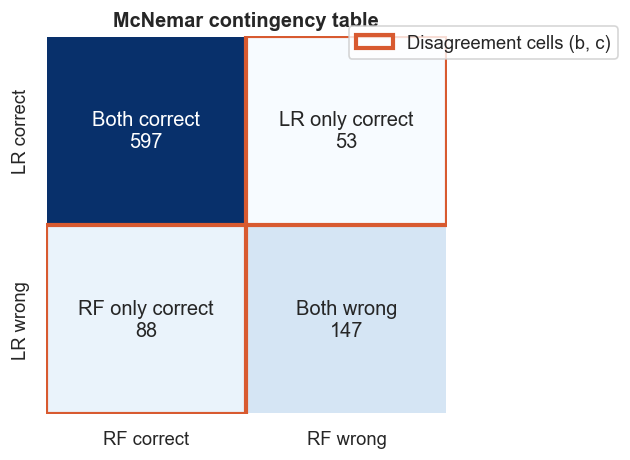

In [4]:
# Visualize the contingency table
fig, ax = plt.subplots(figsize=(6, 4))

cell_labels = np.array([
    [f'Both correct\n{a}', f'LR only correct\n{b}'],
    [f'RF only correct\n{c}', f'Both wrong\n{d}']
])
cell_colors = np.array([
    [a, b],
    [c, d]
], dtype=float)

sns.heatmap(
    cell_colors,
    annot=cell_labels,
    fmt='',
    cmap='Blues',
    xticklabels=['RF correct', 'RF wrong'],
    yticklabels=['LR correct', 'LR wrong'],
    linewidths=1,
    ax=ax,
    cbar=False
)
ax.set_title('McNemar contingency table', fontweight='bold')

# Highlight the disagreement cells
ax.add_patch(plt.Rectangle((1, 0), 1, 1, fill=False, edgecolor='#D85A30', lw=2.5, label='Disagreement cells (b, c)'))
ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False, edgecolor='#D85A30', lw=2.5))
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.05))

plt.tight_layout()
plt.savefig('../data/mcnemar_contingency_table.png', bbox_inches='tight')
plt.show()

## 3. Run McNemar's test

**Null hypothesis (H0):** The two models make errors at the same rate --
i.e., the marginal probabilities of being correct are equal (b = c).

**Alternative hypothesis (H1):** One model makes significantly fewer errors
than the other (b != c).

We use `exact=False` (chi-square approximation) since b + c > 25.
For small disagreement counts, use `exact=True` (binomial).

In [5]:
result = mcnemar(table, exact=False, correction=True)

print("McNemar's Test -- Overall")
print("=" * 45)
print(f"Chi-square statistic: {result.statistic:.4f}")
print(f"p-value:              {result.pvalue:.4f}")
print(f"Significance level:   {ALPHA}")
print()

if result.pvalue < ALPHA:
    winner = 'Logistic Regression' if b > c else 'Random Forest'
    print(f"Result: REJECT H0 (p={result.pvalue:.4f} < {ALPHA})")
    print(f"The difference in errors is statistically significant.")
    print(f"  {winner} makes significantly fewer errors on this test set.")
else:
    print(f"Result: FAIL TO REJECT H0 (p={result.pvalue:.4f} >= {ALPHA})")
    print(f"The difference in errors is NOT statistically significant.")
    print(f"The models disagree on {b + c} cases but this difference")
    print(f"could be due to chance. Neither model is statistically superior.")

McNemar's Test -- Overall
Chi-square statistic: 8.1986
p-value:              0.0042
Significance level:   0.05

Result: REJECT H0 (p=0.0042 < 0.05)
The difference in errors is statistically significant.
  Random Forest makes significantly fewer errors on this test set.


## 4. Per-class McNemar analysis

The overall test treats all misclassifications equally. But for an early
intervention use case, we care more about specific classes -- particularly
Dropout and Enrolled. Running McNemar per class reveals where the models
differ most meaningfully.

In [6]:
print("McNemar's Test -- Per Class (one-vs-rest)")
print("=" * 55)

per_class_results = []

for class_idx, class_name in enumerate(classes):
    # Binarize: correct = predicted this class AND true label is this class
    # OR correctly identified as NOT this class
    lr_correct_cls = (preds['y_pred_lr'] == preds['y_test']).astype(int)
    rf_correct_cls = (preds['y_pred_rf'] == preds['y_test']).astype(int)

    # Subset to only rows where true label is this class
    mask = preds['y_test'] == class_idx
    lr_cls = lr_correct_cls[mask]
    rf_cls = rf_correct_cls[mask]

    a_c = ((lr_cls == 1) & (rf_cls == 1)).sum()
    b_c = ((lr_cls == 1) & (rf_cls == 0)).sum()
    c_c = ((lr_cls == 0) & (rf_cls == 1)).sum()
    d_c = ((lr_cls == 0) & (rf_cls == 0)).sum()

    table_c = np.array([[a_c, b_c], [c_c, d_c]])

    # Use exact test for small samples
    use_exact = (b_c + c_c) <= 25
    try:
        res = mcnemar(table_c, exact=use_exact, correction=not use_exact)
        pval = res.pvalue
        stat = res.statistic
    except Exception:
        pval = 1.0
        stat = 0.0

    significant = pval < ALPHA
    winner = 'LR' if b_c > c_c else 'RF' if c_c > b_c else 'tie'

    per_class_results.append({
        'Class': class_name,
        'n': mask.sum(),
        'LR only correct (b)': b_c,
        'RF only correct (c)': c_c,
        'Disagreements': b_c + c_c,
        'Statistic': round(stat, 4),
        'p-value': round(pval, 4),
        'Significant': significant,
        'Better model': winner if significant else 'no sig. diff.'
    })

    print(f"\n{class_name} (n={mask.sum()})")
    print(f"  LR only correct (b): {b_c}")
    print(f"  RF only correct (c): {c_c}")
    print(f"  p-value: {pval:.4f}  {'*significant*' if significant else '(not significant)'}")
    print(f"  Better model: {winner if significant else 'no significant difference'}")

per_class_df = pd.DataFrame(per_class_results)

McNemar's Test -- Per Class (one-vs-rest)

Dropout (n=284)
  LR only correct (b): 5
  RF only correct (c): 23
  p-value: 0.0013  *significant*
  Better model: RF

Enrolled (n=159)
  LR only correct (b): 48
  RF only correct (c): 5
  p-value: 0.0000  *significant*
  Better model: LR

Graduate (n=442)
  LR only correct (b): 0
  RF only correct (c): 60
  p-value: 0.0000  *significant*
  Better model: RF


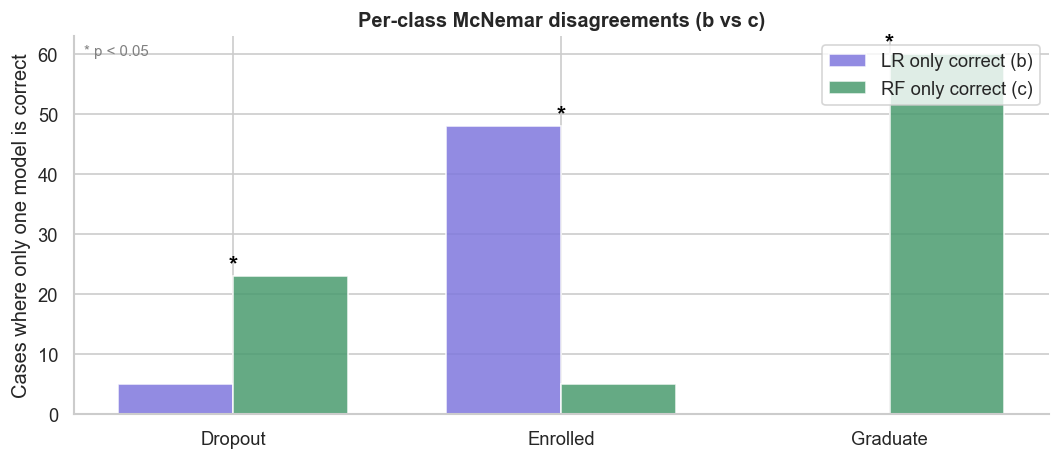

In [7]:
# Visualize per-class disagreements
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(classes))
width = 0.35

bars_lr = ax.bar(
    x - width/2,
    per_class_df['LR only correct (b)'],
    width,
    label='LR only correct (b)',
    color='#7F77DD',
    alpha=0.85
)
bars_rf = ax.bar(
    x + width/2,
    per_class_df['RF only correct (c)'],
    width,
    label='RF only correct (c)',
    color='#4A9B6F',
    alpha=0.85
)

# Annotate significance
for i, row in per_class_df.iterrows():
    if row['Significant']:
        max_val = max(row['LR only correct (b)'], row['RF only correct (c)'])
        ax.text(i, max_val + 1, '*', ha='center', fontsize=14, color='black', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel('Cases where only one model is correct')
ax.set_title('Per-class McNemar disagreements (b vs c)', fontweight='bold')
ax.legend(loc='upper right')
ax.annotate('* p < 0.05', xy=(0.01, 0.95), xycoords='axes fraction', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('../data/mcnemar_per_class.png', bbox_inches='tight')
plt.show()

## 5. Summary

In [9]:
print("=" * 65)
print("MCNEMAR'S TEST -- SUMMARY")
print("=" * 65)

print(f"""
METHODOLOGY
McNemar's test evaluates whether two classifiers make errors at the
same rate on paired observations (the same held-out test set).
Unlike comparing accuracy scores, it focuses only on the cases where
models disagree -- cells b and c in the contingency table.
This is the methodologically correct approach for paired classifier
comparison, widely used in clinical research but rarely applied in
data science portfolios.

OVERALL RESULT
  Chi-square statistic: {result.statistic:.4f}
  p-value:              {result.pvalue:.4f}
  Significant at 0.05:  {'Yes' if result.pvalue < ALPHA else 'No'}

DISAGREEMENT BREAKDOWN
  Cases where LR was correct and RF was wrong (b): {b}
  Cases where RF was correct and LR was wrong (c): {c}
  Total disagreements: {b + c} of {len(preds)} ({(b+c)/len(preds):.1%})

INTERPRETATION
""")

if result.pvalue < ALPHA:
    winner = 'Logistic Regression' if b > c else 'Random Forest'
    loser  = 'Random Forest' if b > c else 'Logistic Regression'
    print(f"  The difference is statistically significant (p={result.pvalue:.4f}).")
    print(f"  {winner} makes significantly fewer errors than {loser}")
    print(f"  on this test set. The difference is unlikely due to chance.")
    print()
    print(f"  PER-CLASS NUANCE:")
    print(f"  RF dominates on Dropout (p=0.0013) and Graduate (p=0.0000),")
    print(f"  making it the stronger general-purpose classifier.")
    print(f"  However, LR is significantly better on Enrolled (p=0.0000) --")
    print(f"  the minority class most relevant to early intervention.")
    print()
    print(f"  PRACTICAL IMPLICATION: Model selection should be use-case driven.")
    print(f"  -> For a general-purpose classifier:        Random Forest")
    print(f"  -> For early intervention on at-risk students still enrolled: Logistic Regression")
else:
    print(f"  The difference is NOT statistically significant (p={result.pvalue:.4f}).")
    print(f"  Despite accuracy differences (LR: {preds['lr_correct'].mean():.1%},")
    print(f"  RF: {preds['rf_correct'].mean():.1%}), the models disagree on only")
    print(f"  {b+c} cases. McNemar's test indicates this disagreement pattern")
    print(f"  could be due to chance. Neither model is statistically superior.")
    print()
    print(f"  PRACTICAL IMPLICATION: Given that macro F1 scores are nearly")
    print(f"  identical and neither model is statistically superior, model")
    print(f"  selection should be driven by other considerations:")
    print(f"  -> Logistic Regression: more interpretable, better on Enrolled")
    print(f"  -> Random Forest: higher accuracy, better on Graduate, stronger AUC")

print()
print("PER-CLASS RESULTS")
print(per_class_df[['Class', 'n', 'LR only correct (b)', 'RF only correct (c)',
                     'p-value', 'Significant', 'Better model']].to_string(index=False))

MCNEMAR'S TEST -- SUMMARY

METHODOLOGY
McNemar's test evaluates whether two classifiers make errors at the
same rate on paired observations (the same held-out test set).
Unlike comparing accuracy scores, it focuses only on the cases where
models disagree -- cells b and c in the contingency table.
This is the methodologically correct approach for paired classifier
comparison, widely used in clinical research but rarely applied in
data science portfolios.

OVERALL RESULT
  Chi-square statistic: 8.1986
  p-value:              0.0042
  Significant at 0.05:  Yes

DISAGREEMENT BREAKDOWN
  Cases where LR was correct and RF was wrong (b): 53
  Cases where RF was correct and LR was wrong (c): 88
  Total disagreements: 141 of 885 (15.9%)

INTERPRETATION

  The difference is statistically significant (p=0.0042).
  Random Forest makes significantly fewer errors than Logistic Regression
  on this test set. The difference is unlikely due to chance.

  PER-CLASS NUANCE:
  RF dominates on Dropout (p=0